In [7]:
#импортирую библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# открываю базу данных и удаляю строки, в которых есть пустыме ячейки
fname = "C:\\Users\\alexandra\\Documents\\Statistics\\flights_NY.csv"
df = pd.read_csv(fname)
df.dropna(inplace=True)

<h1>Задание 1.</h1>

Выберите авиакомпании, которые для перелетов из Нью-Йорка использовали более 200 различных самолетов, и для каждой из них оцените вероятность задержки вылета. Результаты изобразите на графике, отсортировав авиакомпании по убыванию числа самолетов. Для какой авиакомпании вероятность окажется наибольшей? 

carrier   # airplanes  delay probability
DL        626          0.32
UA        620          0.47
AA        600          0.32
WN        581          0.54
EV        316          0.45
US        289          0.24
MQ        237          0.32
9E        203          0.40


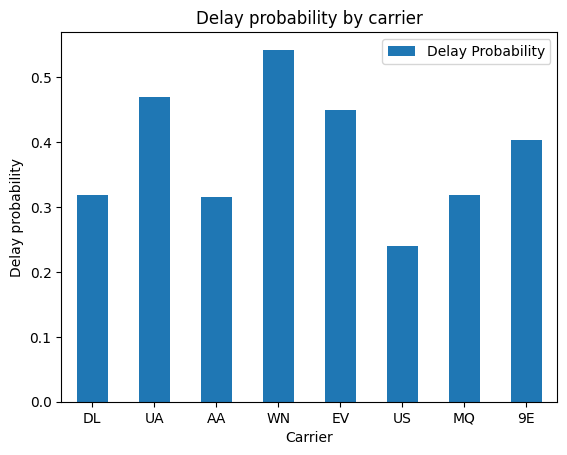

Авиакомпания с наибольшей вероятностью задержки:  WN


In [2]:
# подсчёт количества разных самолётов у авиакомпаний и выбор авиакомпаний, у которых больше 200 самолётов
airplains_by_carrier = df.groupby("carrier")["tailnum"].nunique().sort_values(ascending=False)
carriers = [i for i, v  in airplains_by_carrier.items() if v > 200]
plot_data = []
# определение вероятности задержки
print('carrier   # airplanes  delay probability')
for c in carriers: # для каждой авиакомпании из списка carriers находим:
    count_all     = df[df["carrier"] == c].shape[0]    # общее число рейсов
    count_delayed = df[(df["carrier"] == c) & (df["dep_delay"] > 0)].shape[0]   # число задержанных рейсов
    delay_prob    = count_delayed / count_all   # вероятность задержки
    print(f'{c:<10}{airplains_by_carrier[c]:<13}{delay_prob:.2f}')
    plot_data.append(delay_prob)  
df1 = pd.DataFrame({'Delay Probability': plot_data}, index=carriers)
# график
df1.plot(kind='bar', xlabel='Carrier', ylabel='Delay probability', title='Delay probability by carrier', rot=0)
plt.show()

print("Авиакомпания с наибольшей вероятностью задержки: ", carriers[plot_data.index(max(plot_data))])


<h1>Задание 2.</h1>

Для каждого самолета найдите среднее время, которое он проводит в воздухе, и постройте гистограмму на основе полученных значений. Предполагая, что это распределение описывается нормальным законом, оцените параметры нормального закона и наложите график плотности полученного нормального закона на график с гистограммой. В каких пределах лежит среднее время для 95% всех самолетов?

мат.ожидание: 157.4966402284288, дисперсия: 5746.397731908252, ср.кв.отклонение: 75.80499806680461
График нормирован


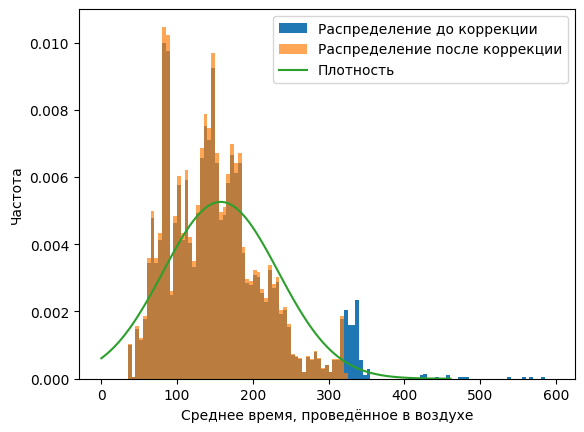

среднее время для 95% всех самолетов лежит в пределах от 58.18 до 283.59 минут


In [3]:
# определение среднего времени в воздухе для каждого самолёта
mean_airtime_by_tailnumber = df.groupby("tailnum")["air_time"].mean()
df1 = pd.DataFrame({'Air time': mean_airtime_by_tailnumber.values})

# исключение выбросов методом интерквартильного размаха
quantiles = df1['Air time'].quantile([0.25, 0.5, 0.75])
iqr = quantiles[0.75] - quantiles[0.25]
lb = quantiles[0.25] - 1.5 * iqr
ub = quantiles[0.75] + 1.5 * iqr
df2 = df1[(df1['Air time'] > lb) & (df1['Air time'] < ub)]

# определение параметров нормального распределения
mean = df1['Air time'].mean()
variance = df1['Air time'].var()
sigma = variance ** 0.5
print(f'мат.ожидание: {mean}, дисперсия: {variance}, ср.кв.отклонение: {sigma}')

# графики: до и после исключения выбросов; график плотности предполагаемого распределения
bins = list(range(0,600,5)) # интервалы
axes = plt.gca()
df1.plot(kind='hist', bins=bins, density=True, ax=axes)
df2.plot(kind='hist', bins=bins, density=True, ax=axes, alpha=0.7)
x = np.linspace(0, mean + 4*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mean, sigma), label='density')
plt.xlabel("Среднее время, проведённое в воздухе")
plt.ylabel("Частота")
plt.legend(["Распределение до коррекции", "Распределение после коррекции", "Плотность"], loc='best')

print("График нормирован")
plt.show()

q = df2['Air time'].quantile([0.025, 0.975])
print(f'среднее время для 95% всех самолетов лежит в пределах от {q[0.025]:.2f} до {q[0.975]:.2f} минут')
s1 = df2.size
s2 = df2[(df2['Air time'] > q[0.025]) & (df2['Air time'] < q[0.975])].size


<h1>Задание 3.</h1>

Значимо ли различаются распределения средней скорости самолетов между авиакомпаниями WN и UА? Подтвердите вывод статистическим тестом. Нарисуйте графики распределений, отметьте на них средние значение и доверительный интервал с уровнем доверия 0.95 для среднего.


p_value = 0.0: распределения средней скорости самолетов между авиакомпаниями WN и UА различаются значимо



WN: Среднее: 400.53, ошибка среднего: 0.35, доверительный интервал: 399.85 - 401.22
UA: Среднее: 420.88, ошибка среднего: 0.20, доверительный интервал: 420.49 - 421.28


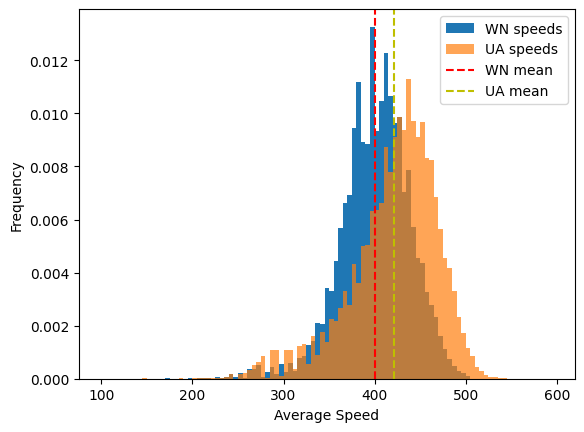

In [4]:
# сравнение средних значений скорости для авиакомпаний WN и UA 
df['speed'] = df['distance'] / df['air_time'] * 60 # добавляю столбец со скоростями
data_wn = df[df['carrier'] == 'WN']['speed'].values # создаю массив со значениями скоростей для WN
data_ua = df[df['carrier'] == 'UA']['speed'].values # создаю массив со значениями скоростей для UA
t_stat, p_value = stats.ttest_ind(data_wn, data_ua) # проверка равенства средних скоростей
print(f'\np_value = {p_value}: распределения средней скорости самолетов между авиакомпаниями WN и UА ', end='')
if p_value < 0.05:
    print('различаются значимо')
else:
    print('не имеют статистически значимых различий')

# построение доверительного интервала для среднего
wn_mean = data_wn.mean()
wn_sem = stats.sem(data_wn)
wn_ci = stats.t.interval(0.95, len(data_wn)-1, loc=wn_mean, scale=wn_sem)
ua_mean = np.mean(data_ua)
ua_sem = stats.sem(data_ua)
ua_ci = stats.t.interval(0.95, len(data_ua)-1, loc=ua_mean, scale=ua_sem)

print("\n\n")
print(f'WN: Среднее: {wn_mean:.2f}, ошибка среднего: {wn_sem:.2f}, доверительный интервал: {wn_ci[0]:.2f} - {wn_ci[1]:.2f}')
print(f'UA: Среднее: {ua_mean:.2f}, ошибка среднего: {ua_sem:.2f}, доверительный интервал: {ua_ci[0]:.2f} - {ua_ci[1]:.2f}')

# графики
df_wn = pd.DataFrame({'WN speeds': data_wn})
df_ua = pd.DataFrame({'UA speeds': data_ua})
bins = list(range(100,600,5))
axes = plt.gca()
df_wn.plot(kind='hist',  bins=bins, density=True, ax=axes)
df_ua.plot(kind='hist', bins=bins,  density=True, ax=axes, alpha=0.7)
plt.xlabel("Average Speed")
axes.axvline(wn_mean, linestyle='--', label='WN mean', c='r')
axes.axvline(ua_mean, linestyle='--', label='UA mean', c='y')
plt.legend(["WN speeds", "UA speeds", "WN mean", "UA mean"], loc='best')
plt.show()


<h1>Задание 4.</h1>

Используя модель линейной регрессии, найдите зависимость среднего расстояния, на которое летает самолет, от его средней скорости (при необходимости, используйте полиномиальные признаки и/или другие преобразования признаков). Постройте график, содержащий данные и полученную зависимость.

<h1>Задание 5.</h1>

Методом кластерного анализа разделите самолеты на группы на основе пары признаков: средняя скорость и число выполненных рейсов. Постройте точечную диаграмму на основе этих пар признаков и отметьте кластеры разными цветами. Можно ли предложить интерпретацию для образовавшихся кластеров (хотя бы для некоторых)?